## Imports

In [73]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from neuralprophet import NeuralProphet
# xgboost
from xgboost import XGBRegressor
import optuna
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

In [2]:
# Verify cuda is a available
import torch

print(torch.__version__)
print(torch.cuda.is_available())      # Should be True
# print(torch.cuda.get_device_name(0))  # Should show your GPU name

2.5.1+cu121
True


In [3]:
RANDOM_STATE = 42

## Visualization Setup

In [4]:
font_path = '/usr/share/fonts/noto_sans_mono/NotoSansMono_SemiCondensed-SemiBold.ttf'
font_prop = fm.FontProperties(fname=font_path)

sns.set_theme(
    style='darkgrid',
    context='notebook',
    font=font_prop.get_name(),
    rc={
        'font.weight': 'semibold',
        'axes.labelweight': 'semibold',
        'axes.titlesize': 'large',
        'axes.titleweight': 'semibold',
        'axes.labelsize': 'medium',
        }
    )

## Load Data

In [5]:
pjmw_df = pd.read_csv('data/PJMW_hourly.csv')

In [6]:
pjmw_df.shape

(143206, 2)

In [7]:
pjmw_df.isna().sum()

Datetime    0
PJMW_MW     0
dtype: int64

In [8]:
pjmw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143206 entries, 0 to 143205
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  143206 non-null  object 
 1   PJMW_MW   143206 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.2+ MB


In [9]:
pjmw_df.head()

,Datetime,PJMW_MW
0,2002-12-31 01:00:00,5077.0
1,2002-12-31 02:00:00,4939.0
2,2002-12-31 03:00:00,4885.0
3,2002-12-31 04:00:00,4857.0
4,2002-12-31 05:00:00,4930.0


In [10]:
pjmw_df.rename(columns={'Datetime': 'datetime', 'PJMW_MW': 'mw'}, inplace=True)

In [11]:
pjmw_df['datetime'] = pd.to_datetime(pjmw_df['datetime'])
pjmw_df['year'] = pjmw_df['datetime'].dt.year
pjmw_df['month'] = pjmw_df['datetime'].dt.month
pjmw_df['day'] = pjmw_df['datetime'].dt.day
pjmw_df['hour'] = pjmw_df['datetime'].dt.hour
pjmw_df['day_of_week'] = pjmw_df['datetime'].dt.dayofweek
pjmw_df['day_of_year'] = pjmw_df['datetime'].dt.dayofyear
pjmw_df['week_of_year'] = pjmw_df['datetime'].dt.isocalendar().week
pjmw_df['quarter'] = pjmw_df['datetime'].dt.quarter

## EDA

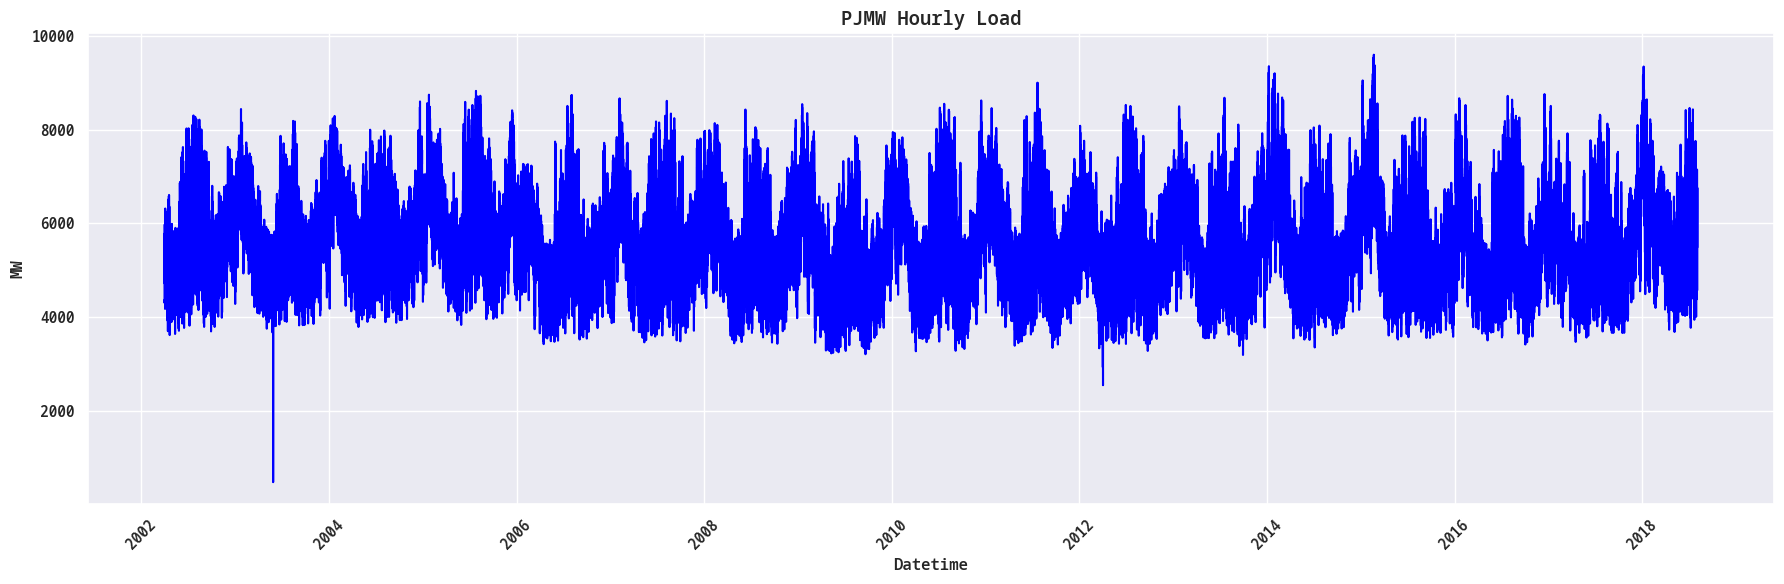

<IPython.core.display.Javascript object>

In [12]:
fig, ax = plt.subplots(figsize=(18, 6))

sns.lineplot(
        data=pjmw_df,
        x='datetime',
        y='mw',
        ax=ax,
        color='blue',
        linewidth=1.5
        )

ax.set_title('PJMW Hourly Load')
ax.set_xlabel('Datetime')
ax.set_ylabel('MW')
ax.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
pjmw_df.head()

,datetime,mw,year,month,day,hour,day_of_week,day_of_year,week_of_year,quarter
0,2002-12-31 01:00:00,5077.0,2002,12,31,1,1,365,1,4
1,2002-12-31 02:00:00,4939.0,2002,12,31,2,1,365,1,4
2,2002-12-31 03:00:00,4885.0,2002,12,31,3,1,365,1,4
3,2002-12-31 04:00:00,4857.0,2002,12,31,4,1,365,1,4
4,2002-12-31 05:00:00,4930.0,2002,12,31,5,1,365,1,4


Let's see how each of the time features correlates with the load (MW).

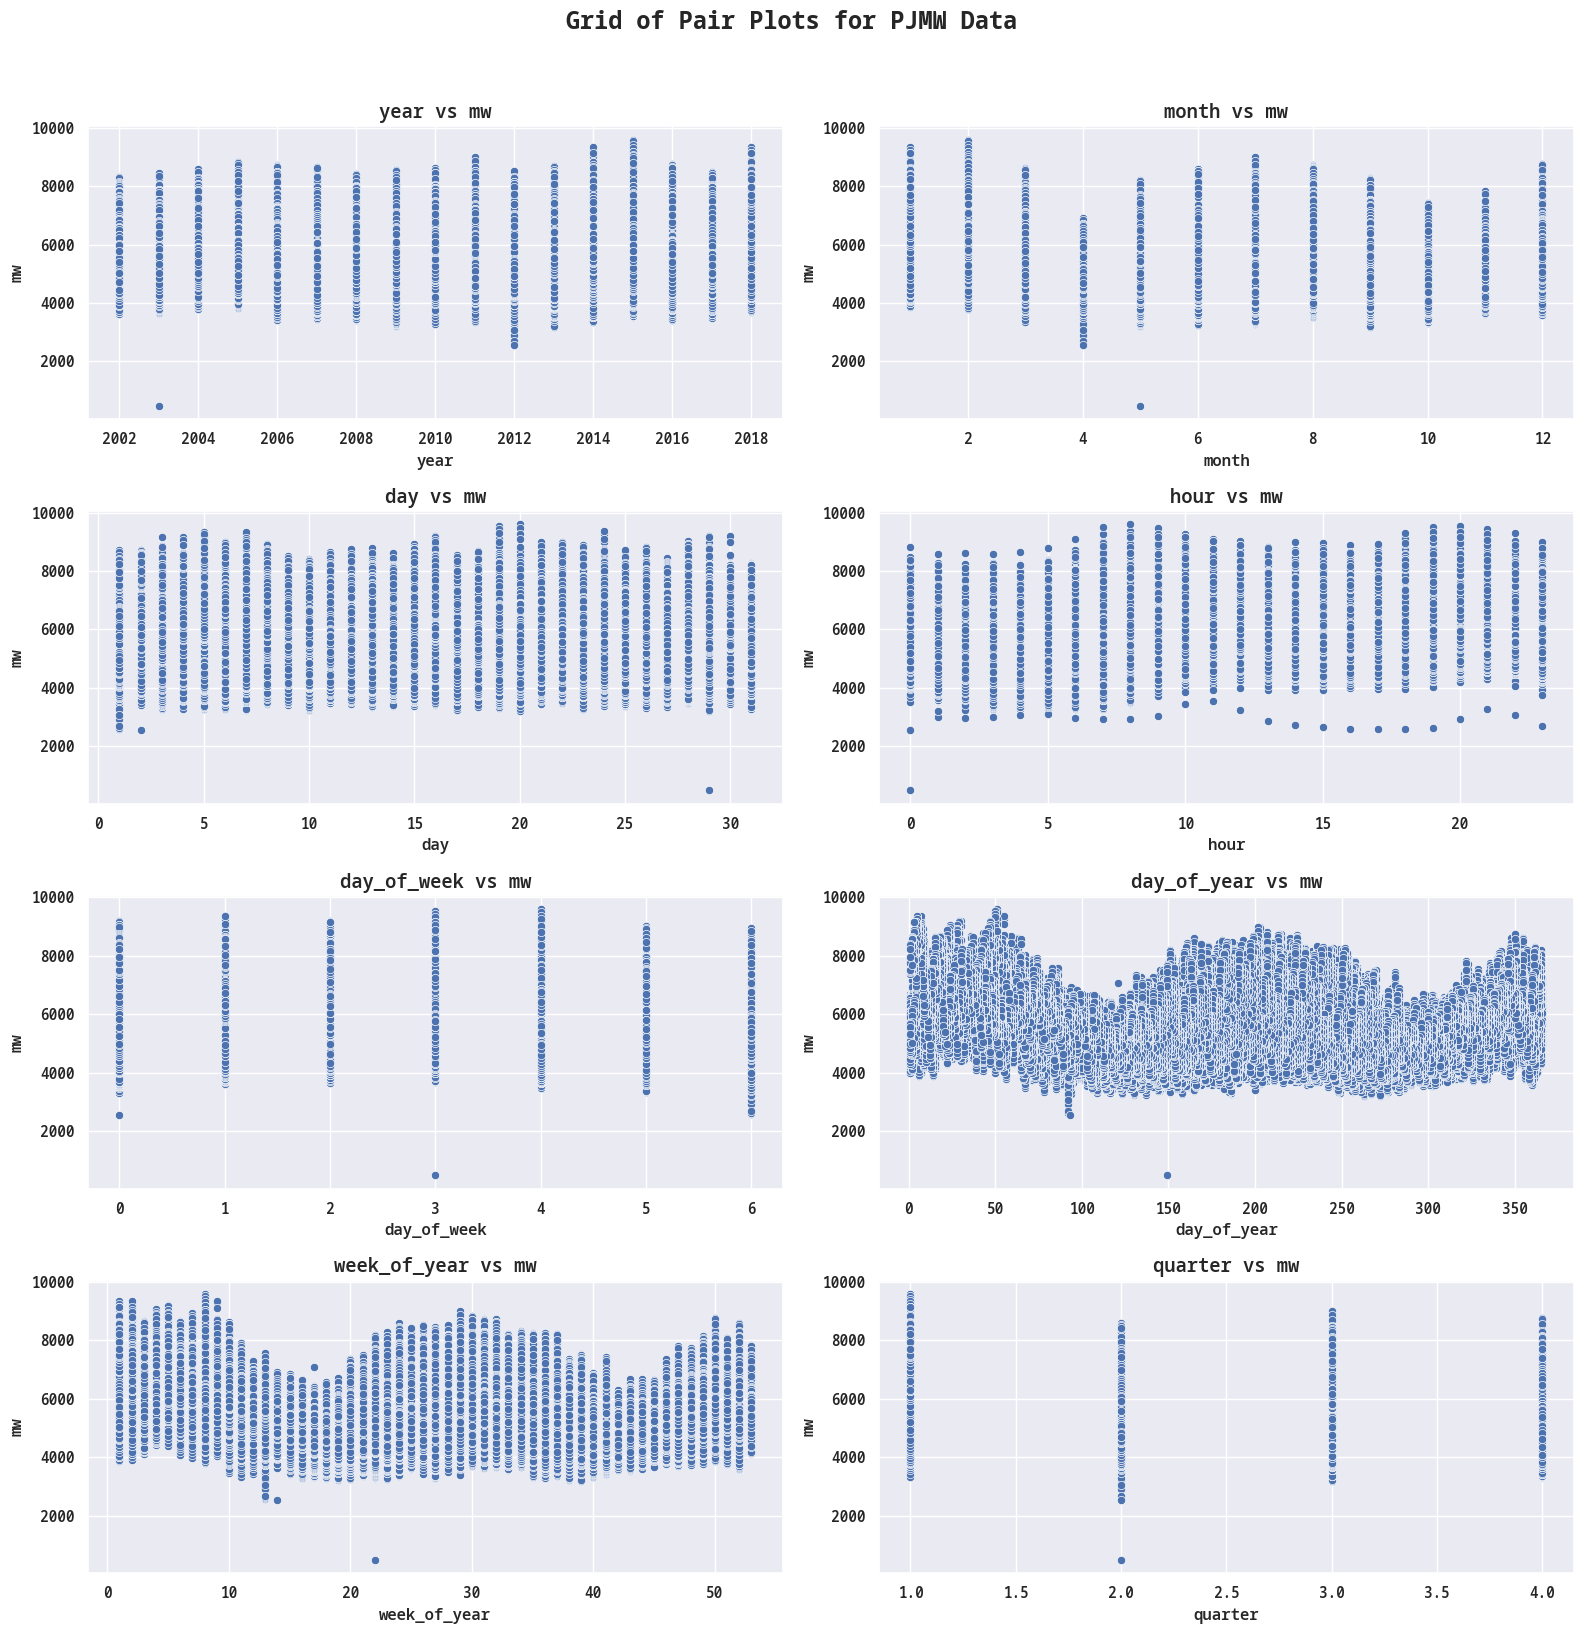

In [14]:
x_vars = [
    'year',
    'month',
    'day',
    'hour',
    'day_of_week',
    'day_of_year',
    'week_of_year',
    'quarter'
]

fig, axes = plt.subplots(4, 2, figsize=(16, 16))  # 4 rows, 2 columns
axes = axes.flatten()

for i, var in enumerate(x_vars):
    sns.scatterplot(data=pjmw_df, x=var, y='mw', ax=axes[i])
    axes[i].set_title(f'{var} vs mw')

plt.suptitle('Grid of Pair Plots for PJMW Data', fontsize=18, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
train_val_test_df = pjmw_df.copy()[['datetime', 'mw']]. \
        rename(columns={'datetime': 'ds', 'mw': 'y'}). \
        sort_values(by='ds'). \
        reset_index(drop=True)

train_val_test_df.head()

,ds,y
0,2002-04-01 01:00:00,4374.0
1,2002-04-01 02:00:00,4306.0
2,2002-04-01 03:00:00,4322.0
3,2002-04-01 04:00:00,4359.0
4,2002-04-01 05:00:00,4436.0


In [16]:
train_val_test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143206 entries, 0 to 143205
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   ds      143206 non-null  datetime64[ns]
 1   y       143206 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 2.2 MB


### Some sanity checks

In [17]:
train_val_test_df['ds'].min(), train_val_test_df['ds'].max()

(Timestamp('2002-04-01 01:00:00'), Timestamp('2018-08-03 00:00:00'))

In [18]:
train_val_test_df.isna().sum()

ds    0
y     0
dtype: int64

In [19]:
train_val_test_df['ds'].value_counts().value_counts()

count
1    143198
2         4
Name: count, dtype: int64

In [20]:
value_counts = train_val_test_df['ds'].value_counts()
value_counts[value_counts > 1].sort_values(ascending=False)

ds
2017-11-05 02:00:00    2
2016-11-06 02:00:00    2
2014-11-02 02:00:00    2
2015-11-01 02:00:00    2
Name: count, dtype: int64

In [21]:
train_val_test_df['ds'].duplicated().sum()

4

In [22]:
train_val_test_df[train_val_test_df['ds'].duplicated(keep=False)].sort_values(by='ds')

,ds,y
110327,2014-11-02 02:00:00,4571.0
110328,2014-11-02 02:00:00,4613.0
119063,2015-11-01 02:00:00,3927.0
119064,2015-11-01 02:00:00,3832.0
127967,2016-11-06 02:00:00,4114.0
127968,2016-11-06 02:00:00,4089.0
136703,2017-11-05 02:00:00,3984.0
136704,2017-11-05 02:00:00,4042.0


Let's drop duplicates and keep the last entry

In [23]:
train_val_test_df = train_val_test_df.drop_duplicates(
        subset='ds',
        keep='last'
        ).reset_index(drop=True)

In [24]:
total_days = (train_val_test_df['ds'].max() - train_val_test_df['ds'].min()).days

train_days = int(0.7 * total_days)
val_days   = int(0.15 * total_days)
test_days  = total_days - train_days - val_days

train_end = train_val_test_df['ds'].min() + pd.Timedelta(days=train_days)
val_end   = train_end + pd.Timedelta(days=val_days)

train_df = train_val_test_df[train_val_test_df['ds'] <= train_end]
val_df   = train_val_test_df[(train_val_test_df['ds'] > train_end) & (train_val_test_df['ds'] <= val_end)]
test_df  = train_val_test_df[train_val_test_df['ds'] > val_end]

In [67]:
# Define the horizon for the Prophet model to predict
horizon_hours = 168  # in hours

In [25]:
# print size, min and max dates of each set
print(f"Train set:      {train_df.shape}, {train_df['ds'].min()} - {train_df['ds'].max()}")
print(f"Validation set: {val_df.shape}, {val_df['ds'].min()} - {val_df['ds'].max()}")
print(f"Test set:       {test_df.shape}, {test_df['ds'].min()} - {test_df['ds'].max()}")

Train set:      (100201, 2), 2002-04-01 01:00:00 - 2013-09-06 01:00:00
Validation set: (21477, 2), 2013-09-06 02:00:00 - 2016-02-18 01:00:00
Test set:       (21524, 2), 2016-02-18 02:00:00 - 2018-08-03 00:00:00


In [26]:
# print the number of NAs in each set

print(f"Train set NAs:      {train_df.isna().sum().sum()}")
print(f"Validation set NAs: {val_df.isna().sum().sum()}")
print(f"Test set NAs:       {test_df.isna().sum().sum()}")

Train set NAs:      0
Validation set NAs: 0
Test set NAs:       0


In [27]:
def objective_prophet(trial):
    params = {
        "changepoint_prior_scale": trial.suggest_float("changepoint_prior_scale", 0.001, 0.5, log=True),
        "seasonality_prior_scale": trial.suggest_float("seasonality_prior_scale", 0.01, 10.0, log=True),
        "holidays_prior_scale":    trial.suggest_float("holidays_prior_scale", 0.01, 10.0, log=True),
        "seasonality_mode":        trial.suggest_categorical("seasonality_mode", ["additive", "multiplicative"]),
        "changepoint_range":       trial.suggest_float("changepoint_range", 0.8, 0.95),
        # 95% confidence interval
        "interval_width": 0.95,
    }

    model = Prophet(**params)
    model.fit(train_df)

    # Forecast on validation
    # future_df = model.make_future_dataframe(periods=len(val_df), freq='H')
    # forecast_df = model.predict(future_df.tail(len(val_df)))

    # # Match forecast to actuals
    # y_pred = forecast_df['yhat'].values
    # y_true = val_df['y'].values

    # return mean_absolute_error(y_true, y_pred)

    # Cross-validation
    df_cv = cross_validation(
        model,
        initial='180 days',    # Use 6 months for training window
        period='7 days',       # Retrain every 7 days
        horizon=f'{horizon_hours} hours',    # Forecast 1 day ahead
        parallel="processes"   # Optional: parallelizes across cores
    )

    # Evaluate using MAE (can use other metrics if needed)
    df_p = performance_metrics(df_cv, rolling_window=1)
    mae = df_p['mae'].mean()

    return mae

In [71]:
%%time

df_cv = cross_validation(
    best_prophet_model,
    initial='1095 days',     # 3 years
    period='180 days',       # Evaluate every 6 months
    horizon='168 hours',     # Forecast 1 week ahead
    parallel="processes"
)

df_cv.shape

08:40:15 - cmdstanpy - INFO - Chain [1] start processing
08:40:17 - cmdstanpy - INFO - Chain [1] start processing
08:40:18 - cmdstanpy - INFO - Chain [1] start processing
08:40:18 - cmdstanpy - INFO - Chain [1] start processing
08:40:20 - cmdstanpy - INFO - Chain [1] start processing
08:40:20 - cmdstanpy - INFO - Chain [1] start processing
08:40:20 - cmdstanpy - INFO - Chain [1] start processing
08:40:21 - cmdstanpy - INFO - Chain [1] start processing
08:40:22 - cmdstanpy - INFO - Chain [1] start processing
08:40:22 - cmdstanpy - INFO - Chain [1] start processing
08:40:25 - cmdstanpy - INFO - Chain [1] start processing
08:40:25 - cmdstanpy - INFO - Chain [1] start processing
08:46:45 - cmdstanpy - INFO - Chain [1] done processing
08:46:46 - cmdstanpy - INFO - Chain [1] done processing
08:47:08 - cmdstanpy - INFO - Chain [1] start processing
08:47:10 - cmdstanpy - INFO - Chain [1] start processing
08:48:10 - cmdstanpy - INFO - Chain [1] done processing
08:48:31 - cmdstanpy - INFO - Chai

CPU times: user 7.62 s, sys: 1.48 s, total: 9.09 s
Wall time: 17min 9s


(3023, 6)

<IPython.core.display.Javascript object>

In [74]:
df_p = performance_metrics(df_cv, rolling_window=1)
mae = df_p['mae'].mean()

In [76]:
mae

467.39455762817846

In [28]:
%%time

study = optuna.create_study(direction="minimize")
study.optimize(objective_prophet, n_trials=50, timeout=600, n_jobs=4)
best_prophet_params = study.best_params.copy()

print("Best parameters:", study.best_params)
print("Best validation MAE:", study.best_value)

[I 2025-06-17 07:51:37,960] A new study created in memory with name: no-name-035a6b4d-cc37-4a21-afa3-37dab438f923
07:51:56 - cmdstanpy - INFO - Chain [1] start processing
07:51:58 - cmdstanpy - INFO - Chain [1] start processing
07:51:58 - cmdstanpy - INFO - Chain [1] start processing
07:52:00 - cmdstanpy - INFO - Chain [1] start processing
07:52:53 - cmdstanpy - INFO - Chain [1] done processing
[I 2025-06-17 07:53:01,169] Trial 1 finished with value: 611.3663272789712 and parameters: {'changepoint_prior_scale': 0.0013308794350492528, 'seasonality_prior_scale': 4.452593178902862, 'holidays_prior_scale': 0.05894516856613071, 'seasonality_mode': 'additive', 'changepoint_range': 0.9139886052852253}. Best is trial 1 with value: 611.3663272789712.
07:53:10 - cmdstanpy - INFO - Chain [1] start processing
07:54:22 - cmdstanpy - INFO - Chain [1] done processing
[I 2025-06-17 07:54:31,512] Trial 4 finished with value: 609.4576131787229 and parameters: {'changepoint_prior_scale': 0.00104813021626

Best parameters: {'changepoint_prior_scale': 0.2945271671590609, 'seasonality_prior_scale': 8.950153971001782, 'holidays_prior_scale': 0.7941575101107958, 'seasonality_mode': 'multiplicative', 'changepoint_range': 0.8016950330637751}
Best validation MAE: 606.1734206767617
CPU times: user 3min 34s, sys: 38.9 s, total: 4min 13s
Wall time: 12min 31s


<IPython.core.display.Javascript object>

In [29]:
best_prophet_model = Prophet(**best_prophet_params)
best_prophet_model.fit(train_df)

08:04:14 - cmdstanpy - INFO - Chain [1] start processing
08:05:29 - cmdstanpy - INFO - Chain [1] done processing


<IPython.core.display.Javascript object>

In [30]:
model = best_prophet_model
future_df = model.make_future_dataframe(periods=len(val_df), freq='H')
forecast_df = model.predict(future_df)
forecast_df_val = forecast_df[forecast_df['ds'].isin(val_df['ds'])]

In [31]:
len(val_df)

21477

In [32]:
len(future_df)

121678

In [33]:
len(forecast_df)

121678

In [34]:
len(forecast_df_val)

21474

In [35]:
forecast_df_val.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21474 entries, 100201 to 121677
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   ds                          21474 non-null  datetime64[ns]
 1   trend                       21474 non-null  float64       
 2   yhat_lower                  21474 non-null  float64       
 3   yhat_upper                  21474 non-null  float64       
 4   trend_lower                 21474 non-null  float64       
 5   trend_upper                 21474 non-null  float64       
 6   daily                       21474 non-null  float64       
 7   daily_lower                 21474 non-null  float64       
 8   daily_upper                 21474 non-null  float64       
 9   multiplicative_terms        21474 non-null  float64       
 10  multiplicative_terms_lower  21474 non-null  float64       
 11  multiplicative_terms_upper  21474 non-null  float64  

In [36]:
val_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21477 entries, 100201 to 121677
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      21477 non-null  datetime64[ns]
 1   y       21477 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 503.4 KB


In [37]:
forecast_df_val['ds'].duplicated().sum()

0

In [38]:
val_df['ds'].duplicated().sum()

0

In [39]:
set(val_df['ds'].astype(str).values) - set(forecast_df_val['ds'].astype(str).values)

{'2016-02-17 23:00:00', '2016-02-18 00:00:00', '2016-02-18 01:00:00'}

In [40]:
forecast_df_val['ds'].max()

Timestamp('2016-02-17 22:00:00')

In [41]:
forecast_df_val['ds'].min()

Timestamp('2013-09-06 02:00:00')

In [42]:
def evaluate_model(model, val_df):
    # Forecast on validation
    future_df = model.make_future_dataframe(periods=len(val_df), freq='H')
    forecast_df = model.predict(future_df.tail(len(val_df)))

    # Match forecast to actuals
    y_pred_val = forecast_df['yhat'].values
    y_true_val = val_df['y'].values

    val_mae = mean_absolute_error(y_true_val, y_pred_val)

    return val_mae, y_pred_val, y_true_val

def plot_results(y_true_val, y_pred_val):
    plt.figure(figsize=(14, 7))

    # Validation set
    plt.plot(y_true_val, label='Actual (Validation)', color='blue', alpha=0.7)
    plt.plot(y_pred_val, label='Predicted (Validation)', color='orange', linestyle='--', alpha=0.7)
    plt.title('Validation Set Predictions')
    plt.xlabel('Time')
    plt.ylabel('MW')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [43]:
val_mae, y_pred_val, y_true_val = evaluate_model(
    best_prophet_model, val_df
)

val_mean = val_df['y'].mean()
print(f"Validation MAE: {val_mae:.4f}")
print(f"Validation MAE / Mean: {val_mae / val_mean:.4f}")

Validation MAE: 606.1734
Validation MAE / Mean: 0.1071


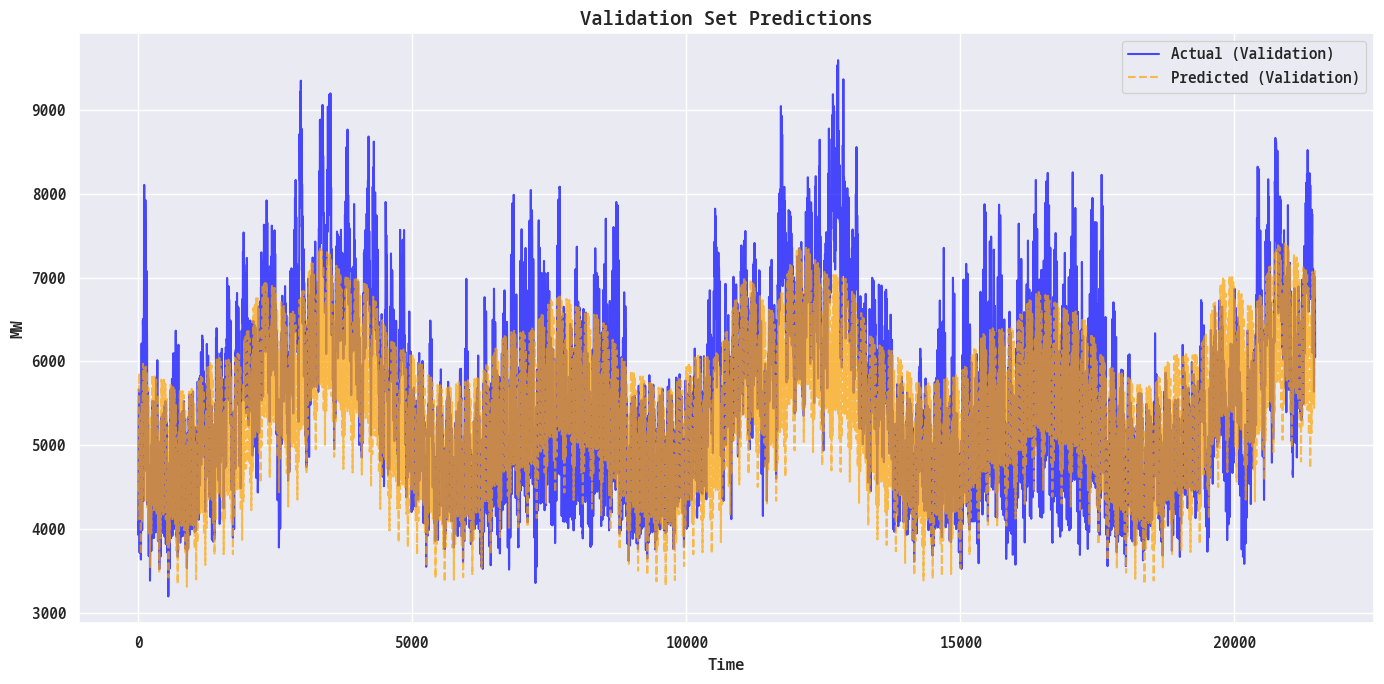

In [44]:
# Plot results
plot_results(y_true_val, y_pred_val)

In [45]:
future_df = model.make_future_dataframe(periods=len(val_df), freq='H')
forecast_df = model.predict(future_df.tail(len(val_df)))
forecast_df

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,daily,daily_lower,daily_upper,multiplicative_terms,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat
0,2013-09-06 02:00:00,5487.434908,3854.684273,5235.289553,5487.434908,5487.434908,-0.152636,-0.152636,-0.152636,-0.169421,...,0.027560,0.027560,0.027560,-0.044345,-0.044345,-0.044345,0.0,0.0,0.0,4557.747847
1,2013-09-06 03:00:00,5487.438038,3715.705282,5120.991321,5487.438038,5487.438038,-0.172643,-0.172643,-0.172643,-0.190377,...,0.026852,0.026852,0.026852,-0.044585,-0.044585,-0.044585,0.0,0.0,0.0,4442.758116
2,2013-09-06 04:00:00,5487.441168,3746.072119,5115.816015,5487.441168,5487.441168,-0.172635,-0.172635,-0.172635,-0.191365,...,0.026095,0.026095,0.026095,-0.044826,-0.044826,-0.044826,0.0,0.0,0.0,4437.335266
3,2013-09-06 05:00:00,5487.444299,3904.891926,5288.704049,5487.444299,5487.444299,-0.151724,-0.151724,-0.151724,-0.171507,...,0.025283,0.025283,0.025283,-0.045065,-0.045065,-0.045065,0.0,0.0,0.0,4546.310822
4,2013-09-06 06:00:00,5487.447429,4058.394263,5429.635403,5487.447429,5487.447429,-0.112227,-0.112227,-0.112227,-0.133126,...,0.024405,0.024405,0.024405,-0.045305,-0.045305,-0.045305,0.0,0.0,0.0,4756.925023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21472,2016-02-17 18:00:00,5554.647786,854.784710,13180.807916,808.331809,10565.456899,0.090978,0.090978,0.090978,0.249059,...,0.038551,0.038551,0.038551,0.119530,0.119530,0.119530,0.0,0.0,0.0,6938.081656
21473,2016-02-17 19:00:00,5554.650917,600.282151,13435.225057,808.014485,10565.748915,0.108541,0.108541,0.108541,0.266842,...,0.038780,0.038780,0.038780,0.119522,0.119522,0.119522,0.0,0.0,0.0,7036.867806
21474,2016-02-17 20:00:00,5554.654047,803.093237,13507.951112,807.697162,10566.040931,0.115892,0.115892,0.115892,0.274368,...,0.038961,0.038961,0.038961,0.119514,0.119514,0.119514,0.0,0.0,0.0,7078.670709
21475,2016-02-17 21:00:00,5554.657177,811.322089,13387.201218,807.379839,10566.332946,0.101101,0.101101,0.101101,0.259701,...,0.039094,0.039094,0.039094,0.119506,0.119506,0.119506,0.0,0.0,0.0,6997.207380


In [46]:
forecast_df.head(1).T

,0
ds,2013-09-06 02:00:00
trend,5487.434908
yhat_lower,3854.684273
yhat_upper,5235.289553
trend_lower,5487.434908
trend_upper,5487.434908
daily,-0.152636
daily_lower,-0.152636
daily_upper,-0.152636
multiplicative_terms,-0.169421


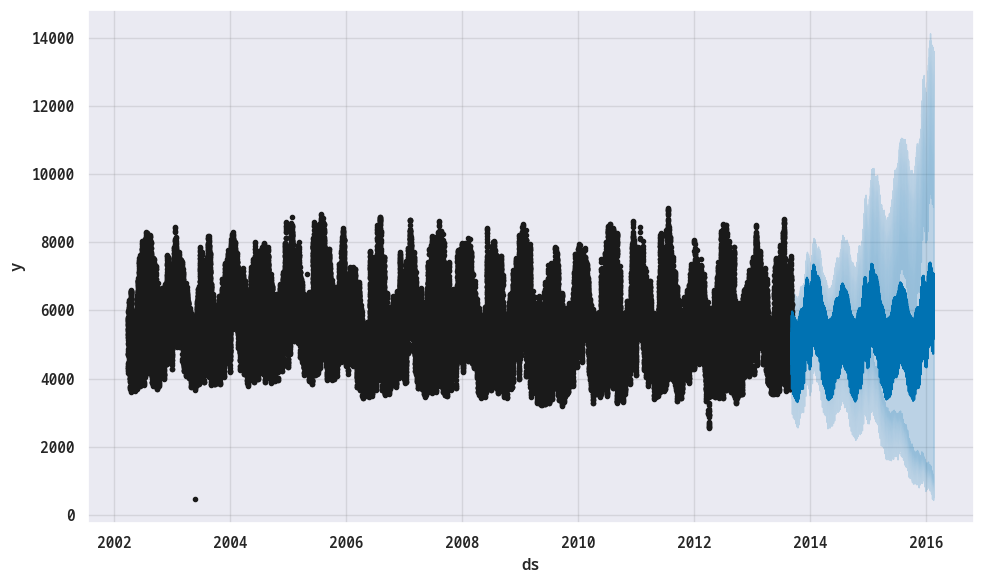

In [69]:
best_prophet_model.plot(forecast_df)
plt.xlim(pd.Timestamp('2013-08-01'), pd.Timestamp('2013-10-31'))
plt.show()

In [47]:
forecast_df.columns

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'daily', 'daily_lower', 'daily_upper', 'multiplicative_terms',
       'multiplicative_terms_lower', 'multiplicative_terms_upper', 'weekly',
       'weekly_lower', 'weekly_upper', 'yearly', 'yearly_lower',
       'yearly_upper', 'additive_terms', 'additive_terms_lower',
       'additive_terms_upper', 'yhat'],
      dtype='object')

In [48]:
forecast_df['y'] = val_df['y'].values
forecast_df['residual'] = forecast_df['yhat'] - forecast_df['y']

In [49]:
residual_train_val_test_df = forecast_df.copy().drop(columns=['y'])

residual_train_val_test_df['day'] = residual_train_val_test_df['ds'].dt.day
residual_train_val_test_df['month'] = residual_train_val_test_df['ds'].dt.month
residual_train_val_test_df['year'] = residual_train_val_test_df['ds'].dt.year
residual_train_val_test_df['hour'] = residual_train_val_test_df['ds'].dt.hour
residual_train_val_test_df['day_of_week'] = residual_train_val_test_df['ds'].dt.dayofweek
residual_train_val_test_df['day_of_year'] = residual_train_val_test_df['ds'].dt.dayofyear
residual_train_val_test_df['week_of_year'] = residual_train_val_test_df['ds'].dt.isocalendar().week
residual_train_val_test_df['quarter'] = residual_train_val_test_df['ds'].dt.quarter

residual_train_val_test_df.drop(columns=['ds'], inplace=True)

X = residual_train_val_test_df.drop(columns=['residual', 'yhat'])
y = residual_train_val_test_df['residual']

# Split: train (60%), val (20%), test (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, test_size=0.2,
        random_state=RANDOM_STATE, shuffle=False
        )

X_train, X_val, y_train, y_val = train_test_split(
        X_train_val,
        y_train_val,
        test_size=0.25,
        random_state=RANDOM_STATE,
        shuffle=False
        )

In [50]:
def objective_xgboost(trial):
    params = {
        'tree_method': 'gpu_hist',
        'predictor': 'gpu_predictor',
        'n_estimators': trial.suggest_int('n_estimators', 50, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state': RANDOM_STATE
    }

    model = XGBRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    y_pred = model.predict(X_val)
    rmse = mean_squared_error(y_val, y_pred, squared=False)  # RMSE

    return rmse

In [51]:
%%time
study_xgb = optuna.create_study(direction="minimize")
study_xgb.optimize(objective_xgboost, n_trials=50, timeout=600)

print("Best parameters for XGBoost:", study_xgb.best_params)
print("Best validation RMSE for XGBoost:", study_xgb.best_value)

[I 2025-06-17 08:05:48,791] A new study created in memory with name: no-name-b6422151-dfb7-4e55-b5f3-15694971396a
[I 2025-06-17 08:05:50,067] Trial 0 finished with value: 668.386515947931 and parameters: {'n_estimators': 150, 'max_depth': 8, 'learning_rate': 0.05624742920075815, 'subsample': 0.7086020122877279, 'colsample_bytree': 0.9857060282248478, 'reg_alpha': 0.4343180141382216, 'reg_lambda': 0.24233621932882066}. Best is trial 0 with value: 668.386515947931.
[I 2025-06-17 08:05:50,820] Trial 1 finished with value: 824.3132848851145 and parameters: {'n_estimators': 350, 'max_depth': 5, 'learning_rate': 0.08789745155604818, 'subsample': 0.8978826484399828, 'colsample_bytree': 0.8408491264798812, 'reg_alpha': 0.9054273357831876, 'reg_lambda': 0.678373496966176}. Best is trial 0 with value: 668.386515947931.
[I 2025-06-17 08:05:52,273] Trial 2 finished with value: 689.9859351860326 and parameters: {'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.012686483041210242, 'subsample'

[I 2025-06-17 08:06:12,713] Trial 23 finished with value: 682.8409867813938 and parameters: {'n_estimators': 100, 'max_depth': 9, 'learning_rate': 0.041151757183365945, 'subsample': 0.714133527325919, 'colsample_bytree': 0.9629019403667262, 'reg_alpha': 0.16773174620673462, 'reg_lambda': 0.1317203596879599}. Best is trial 12 with value: 652.7290841829712.
[I 2025-06-17 08:06:13,301] Trial 24 finished with value: 670.7476728712282 and parameters: {'n_estimators': 50, 'max_depth': 9, 'learning_rate': 0.12614955914863282, 'subsample': 0.6544908876643936, 'colsample_bytree': 0.9542305464096243, 'reg_alpha': 0.3540594601354734, 'reg_lambda': 0.13110881133699426}. Best is trial 12 with value: 652.7290841829712.
[I 2025-06-17 08:06:14,869] Trial 25 finished with value: 679.192188212667 and parameters: {'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.07747409869666123, 'subsample': 0.7372137601888222, 'colsample_bytree': 0.8651529198404714, 'reg_alpha': 0.20746698359721366, 'reg_lambd

[I 2025-06-17 08:06:29,167] Trial 46 finished with value: 659.0083784266907 and parameters: {'n_estimators': 150, 'max_depth': 6, 'learning_rate': 0.01719507891961985, 'subsample': 0.8836250190110434, 'colsample_bytree': 0.7810048263139691, 'reg_alpha': 0.47947375298292405, 'reg_lambda': 0.7980013779700766}. Best is trial 27 with value: 645.1968383891873.
[I 2025-06-17 08:06:29,297] Trial 47 finished with value: 688.6234509537619 and parameters: {'n_estimators': 50, 'max_depth': 4, 'learning_rate': 0.019056917298364992, 'subsample': 0.8576637603569219, 'colsample_bytree': 0.8092119297164795, 'reg_alpha': 0.2365454849946848, 'reg_lambda': 0.9656848594688738}. Best is trial 27 with value: 645.1968383891873.
[I 2025-06-17 08:06:30,404] Trial 48 finished with value: 672.7270054525243 and parameters: {'n_estimators': 250, 'max_depth': 7, 'learning_rate': 0.012298487143122181, 'subsample': 0.813700429920952, 'colsample_bytree': 0.7337991303630196, 'reg_alpha': 0.07800676868961333, 'reg_lambd

Best parameters for XGBoost: {'n_estimators': 50, 'max_depth': 7, 'learning_rate': 0.03203938182600143, 'subsample': 0.7668569449077725, 'colsample_bytree': 0.7914816596067644, 'reg_alpha': 0.38689635381588977, 'reg_lambda': 0.29623903473667246}
Best validation RMSE for XGBoost: 645.1968383891873
CPU times: user 53.7 s, sys: 290 ms, total: 54 s
Wall time: 41.9 s


<IPython.core.display.Javascript object>

In [52]:
best_xgb_model = XGBRegressor(**study_xgb.best_params)
best_xgb_model.fit(X_train_val, y_train_val)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7914816596067644, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03203938182600143, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=7, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=50, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [53]:
corrected_future_df = model.make_future_dataframe(periods=len(test_df), freq='H')
forecast_df_test = model.predict(corrected_future_df.tail(len(test_df)))

In [90]:
def objective_neural_prophet(trial):
    # Define hyperparameters to optimize
    params = {
        'n_lags': trial.suggest_int('n_lags', 5, 30),
        'n_forecasts': trial.suggest_int('n_forecasts', 1, 7),
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-1, log=True),
        'epochs': trial.suggest_int('epochs', 50, 150),
        'batch_size': trial.suggest_categorical('batch_size', [512, 1024, 2048]),
        'loss_func': trial.suggest_categorical('loss_func', ['Huber', 'MAE', 'MSE']),
    }

    try:
        # Create and train model
        model = NeuralProphet(
            n_lags=params['n_lags'],
            n_forecasts=params['n_forecasts'],
            learning_rate=params['learning_rate'],
            epochs=params['epochs'],
            batch_size=params['batch_size'],
            loss_func=params['loss_func'],
            collect_metrics=False
        )

        # Fit model on training data
        model.fit(train_df, freq='H')

        # Make predictions on val data
        future = model.make_future_dataframe(
            train_df,
            periods=len(val_df),
            n_historic_predictions=True
        )
        forecast = model.predict(future)

        # Extract val predictions
        val_pred = forecast.tail(len(val_df))['yhat1'].values
        val_actual = val_df['y'].values

        # Calculate and return MAE
        mae = mean_absolute_error(val_actual, val_pred)
        return mae

    except Exception as e:
        # Return high error for failed trials
        print(f"Trial failed: {e}")
        return float('inf')

In [94]:
def check_train_val_gap(train_df, val_df):
    last_train = train_df['ds'].max()
    first_val = val_df['ds'].min()
    gap_days = (first_val - last_train).days

    print(f"Last training date: {last_train}")
    print(f"First validation date: {first_val}")
    print(f"Gap between train and val: {gap_days} days")

    if gap_days != 1:
        print(f"⚠️  WARNING: Expected 1 day gap, found {gap_days} days")
        return False
    else:
        print("✅ No gap detected")
        return True

# Check your data
check_train_val_gap(train_df, val_df)

Last training date: 2013-09-06 01:00:00
First validation date: 2013-09-06 02:00:00
Gap between train and val: 0 days
⚠️  WARNING: Expected 1 day gap, found 0 days


False

In [95]:
test_model = NeuralProphet()
test_model.fit(train_df, freq='H')

WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency H corresponds to 99.975% of the data.
WARNING - (NP.df_utils._infer_frequency) - Defined frequency D is different than major frequency H
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 256
INFO - (NP.config.set_auto_batch_epoch) - Auto-set epochs to 30


Training: |                                                                                                   …

Finding best initial lr:   0%|          | 0/275 [00:00<?, ?it/s]

Training: |                                                                                                   …

NameError: name 'exit' is not defined

<IPython.core.display.Javascript object>

In [91]:
%%time
study = optuna.create_study(direction="minimize")
study.optimize(objective_neural_prophet, n_trials=50, timeout=600)

print("Best parameters for NeuralProphet:", study.best_params)
print("Best validation MAE for NeuralProphet:", study.best_value)

[I 2025-06-15 18:42:22,550] A new study created in memory with name: no-name-b1756d57-b52d-4cba-9b20-59499a154d14
WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency H corresponds to 99.975% of the data.
WARNING - (NP.df_utils._infer_frequency) - Defined frequency D is different than major frequency H
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.


Training: |                                                                                                   …

Training: |                                                                                                   …

INFO - (NP.df_utils._infer_frequency) - Major frequency H corresponds to 99.975% of the data.
WARNING - (NP.df_utils._infer_frequency) - Defined frequency D is different than major frequency H
WARNING - (NP.data.splitting._make_future_dataframe) - Number of forecast steps is defined by n_forecasts. Adjusted to 7.
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency H corresponds to 99.968% of the data.
WARNING - (NP.df_utils._infer_frequency) - Defined frequency D is different than major frequency H
INFO - (NP.df_utils._infer_frequency) - Major frequency H corresponds to 99.968% of the data.
WARNING - (NP.df_utils._infer_frequency) - Defined frequency D is different than major frequency H
INFO - (NP.data.processing._handle_missing_data) - Dropped 7 rows at the end with NaNs in 'y' column.


Predicting: |                                                                                                 …

...

Training: |                                                                                                   …

2025-06-15T18:52:32.325141+0300 - Timed out waiting for syncing to complete.


[I 2025-06-15 18:52:37,048] Trial 2 finished with value: inf and parameters: {'n_lags': 22, 'n_forecasts': 3, 'learning_rate': 0.00041618301590195004, 'epochs': 50, 'batch_size': 2048, 'loss_func': 'MAE'}. Best is trial 0 with value: inf.


Trial failed: name 'exit' is not defined
Best parameters for NeuralProphet: {'n_lags': 13, 'n_forecasts': 7, 'learning_rate': 0.0008417925260870776, 'epochs': 122, 'batch_size': 2048, 'loss_func': 'MAE'}
Best validation MAE for NeuralProphet: inf
CPU times: user 17min 51s, sys: 1min 38s, total: 19min 29s
Wall time: 10min 14s


<IPython.core.display.Javascript object>

In [ ]:
best_model = NeuralProphet(
    n_lags=study.best_params['n_lags'],
    n_forecasts=study.best_params['n_forecasts'],
    learning_rate=study.best_params['learning_rate'],
    epochs=study.best_params['epochs'],
    batch_size=study.best_params['batch_size'],
    d_hidden=study.best_params['d_hidden'],
    loss_func=study.best_params['loss_func']
)

best_model.fit(train_data, freq='H')

# Final evaluation
future = best_model.make_future_dataframe(
    train_data,
    periods=len(test_data),
    n_historic_predictions=True
)
final_forecast = best_model.predict(future)

final_pred = final_forecast.tail(len(test_data))['yhat1'].values
final_mae = mean_absolute_error(test_data['y'].values, final_pred)

print(f"Final model MAE: {final_mae:.4f}")

In [ ]:
# Optional: Plot results
try:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 6))
    plt.plot(test_data['y'].values, label='Actual', alpha=0.7)
    plt.plot(final_pred, label='Predicted', alpha=0.7)
    plt.title('NeuralProphet Predictions (Optimized)')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.show()

except ImportError:
    print("Matplotlib not available for plotting")

# Show parameter importance
print("\nParameter Importance:")
importance = optuna.importance.get_param_importances(study)
for param, imp in sorted(importance.items(), key=lambda x: x[1], reverse=True):
    print(f"{param}: {imp:.3f}")